In [1]:
from pathlib import Path
import uproot
import numpy as np
from matplotlib import pyplot as plt
import mplhep as hep
from correctionlib import schemav2
import correctionlib

hep.style.use("CMS")

In [2]:
plot_dir = Path("plots/pTjj")
sf_dir = Path("SF")

plot_dir.mkdir(exist_ok=True, parents=True)
sf_dir.mkdir(exist_ok=True)

In [3]:
LUMI_DICT = {
    "2022": 34652.1,
    "2023": 27776.5,
    "2024": 108960.0,
}
YEARS = ("2022", "2023")
ylim_dict = {
    "2022": (1e-1, 1e4),
    "2023": (1e-1, 1e4),
}

In [4]:
def binning(edges, content, var_name):
    return schemav2.Binning(
        nodetype="binning",
        input=var_name,
        edges=edges,
        content=list(content),
        flow="clamp",
    )


def get_corr(edges, val_nom, val_up, val_down, var_name, var_description=""):
    description = f"ttbar SF as a function of {var_name}"
    if not var_description:
        var_description = var_name

    weight = schemav2.Correction(
        name=f"ttbar_SF_{var_name}",
        version=1,
        description=description,
        inputs=[
            schemav2.Variable(
                name=var_name,
                type="real",
                description=var_description,
            ),
            schemav2.Variable(
                name="systematic",
                type="string",
                description="Systematic variation",
            ),
        ],
        output=schemav2.Variable(
            name="weight", type="real", description="Multiplicative event weight"
        ),
        data=schemav2.Category(
            nodetype="category",
            input="systematic",
            content=[
                {"key": "nominal", "value": binning(edges, val_nom, var_name)},
                {"key": "stat_up", "value": binning(edges, val_up, var_name)},
                {"key": "stat_dn", "value": binning(edges, val_down, var_name)},
            ],
            default=binning(edges, val_nom, var_name),
        ),
        generic_formulas=[],
    )
    cset = schemav2.CorrectionSet(
        schema_version=2,
        description=description,
        corrections=[
            weight,
        ],
        compound_corrections=[],
    )

    return cset



In [5]:
mc_stack_order = ["ttbar", "VV+VJ", "QCD", "ttH"]
legend_label_dict = {
    "data": "Data",
    "QCD": "QCD Multijet",
    "ttbar": r"$t\bar{t}$",
    "ttH": r"$t\bar{t}H$",
    # "VJ": "V+jets",
    # "VV": "VV",
    "VV+VJ": "V+jets, VV",
}
color_dict = {
    "QCD": "#3f90da",
    "ttbar": "#832db6",
    "ttH": "#b9ac70",
    "VV+VJ": "#92dadd",
}


In [6]:
corr_dict = {}
for feature_label in ["tau32", "TXbb"]:
    corr_dict[feature_label] = {}
    for year in YEARS:
        corr_file = sf_dir / f"corr_{feature_label}_{year}.json"
        if not corr_file.exists():
            raise FileNotFoundError(f"Correction file {corr_file} does not exist.")

        # Load the correction
        corr = correctionlib.CorrectionSet.from_file(str(corr_file))
        corr_dict[feature_label][year] = corr
        print(f"Loaded correction for {year} from {corr_file}")

Loaded correction for 2022 from SF/corr_tau32_2022.json
Loaded correction for 2023 from SF/corr_tau32_2023.json
Loaded correction for 2022 from SF/corr_TXbb_2022.json
Loaded correction for 2023 from SF/corr_TXbb_2023.json


# Semi-leptonic

In [7]:
dir_trees = Path("../full-hadronic/trees/years")
tree_dict = {}
for year in ("2022", "2023"):
    tree_data = uproot.open(dir_trees / f"Histograms_{year}_data.root")["tree"]
    tree_QCD = uproot.open(dir_trees / f"Histograms_{year}_MC_QCD.root")["tree"]
    tree_ttbar = uproot.open(dir_trees / f"Histograms_{year}_MC_TTbar.root")["tree"]
    tree_ttH = uproot.open(dir_trees / f"Histograms_{year}_MC_ttHto2B.root")["tree"]
    tree_VJ = uproot.open(dir_trees / f"Histograms_{year}_MC_VJ.root")["tree"]
    tree_VV = uproot.open(dir_trees / f"Histograms_{year}_MC_VV.root")["tree"]
    tree_dict[year] = {
        "data": tree_data,
        "QCD": tree_QCD,
        "ttbar": tree_ttbar,
        "ttH": tree_ttH,
        "VJ": tree_VJ,
        "VV": tree_VV,
    }

In [8]:
def get_fullhadronic_mask(tree):
    fatJet1_pt = tree["fatJet1_pt"].array(library="numpy")
    fatJet2_pt = tree["fatJet2_pt"].array(library="numpy")
    
    fatJet1_eta = tree["fatJet1_eta"].array(library="numpy")
    fatJet2_eta = tree["fatJet2_eta"].array(library="numpy")
    
    fatJet1_msoftdrop = tree["fatJet1_msoftdrop"].array(library="numpy")
    fatJet2_msoftdrop = tree["fatJet2_msoftdrop"].array(library="numpy")
    
    fatJet1_GloParT_XbbVsQCD = tree["fatJet1_GloParT_XbbVsQCD"].array(library="numpy")
    fatJet2_GloParT_XbbVsQCD = tree["fatJet2_GloParT_XbbVsQCD"].array(library="numpy")
    
    fatJet1_Tau3OverTau2 = tree["fatJet1_Tau3OverTau2"].array(library="numpy")
    fatJet2_Tau3OverTau2 = tree["fatJet2_Tau3OverTau2"].array(library="numpy")
    
    fatJet2_GloParT_massVis = tree["fatJet2_GloParT_massVis"].array(library="numpy")
    
    return (
        (fatJet1_pt > 450) & (np.abs(fatJet1_eta) < 2.5) & (fatJet1_msoftdrop > 50) & (fatJet1_GloParT_XbbVsQCD > 0.1) & (fatJet1_Tau3OverTau2 < 0.46)
        & (fatJet2_pt > 450) & (np.abs(fatJet2_eta) < 2.5) & (fatJet2_msoftdrop > 50) & (fatJet2_GloParT_XbbVsQCD > 0.1) & (fatJet2_Tau3OverTau2 < 0.46)
        # mass window
        # & (fatJet2_GloParT_massVis >= 90) & (fatJet2_GloParT_massVis <= 160)
    )

## pTjj

In [9]:
feature_dict = {}
for year, trees in tree_dict.items():
    feature_dict[year] = {}
    for sample_name, tree in trees.items():
        mask = get_fullhadronic_mask(tree)
        feature_dict[year][sample_name] = {
            "fatJet1_Tau3OverTau2": tree["fatJet1_Tau3OverTau2"].array(library="numpy")[mask],
            "fatJet1_GloParT_XbbVsQCD": tree["fatJet1_GloParT_XbbVsQCD"].array(library="numpy")[mask],
            "pTjj": tree["pTjj"].array(library="numpy")[mask],
            "weight": tree["weight"].array(library="numpy")[mask],
        }

In [10]:
bins = np.arange(0, 1000+0.001, 100)
# bins = np.arange(0, 1000+0.001, 200)
print(f"Bins: {bins}")


Bins: [   0.  100.  200.  300.  400.  500.  600.  700.  800.  900. 1000.]


In [11]:
kfact = {}
feature_name = "pTjj"
feature_label = "pTjj"

for year, trees in tree_dict.items():

    data_hist = None
    mc_hists = []
    
    for sample_name, tree in trees.items():
        feature = feature_dict[year][sample_name]["fatJet1_GloParT_XbbVsQCD"]
        weights = feature_dict[year][sample_name]["weight"]
        
        # Calculate histogram
        counts, edges = np.histogram(feature, bins=np.arange(0, 1.00001, 0.1), weights=weights)
        
        if sample_name == "data":
            data_hist = counts
        else:
            # Store histograms for ratio calculation
            mc_hists.append(counts)
    
    total_bkg = np.sum(mc_hists, axis=0)
    
    # Avoid division by zero
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = data_hist.sum() / total_bkg.sum()
        # ratio_err = ratio * np.sqrt(1/data_hist.sum() + 1/total_bkg.sum())
        # print(f"Year {year}: Data / Total Bkg = {ratio:.3f} ± {ratio_err    :.3f}")
        kfact[year] = ratio
        
print(f"k-factors: {kfact}")

k-factors: {'2022': 0.62233895, '2023': 1.061619}


Year: 2022, Ratios: [1.19524046 1.15155681 1.00429879 0.72311038 1.51206962 0.37967096
 1.         1.         1.         1.        ]


/tmp/ipykernel_3609956/356459340.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


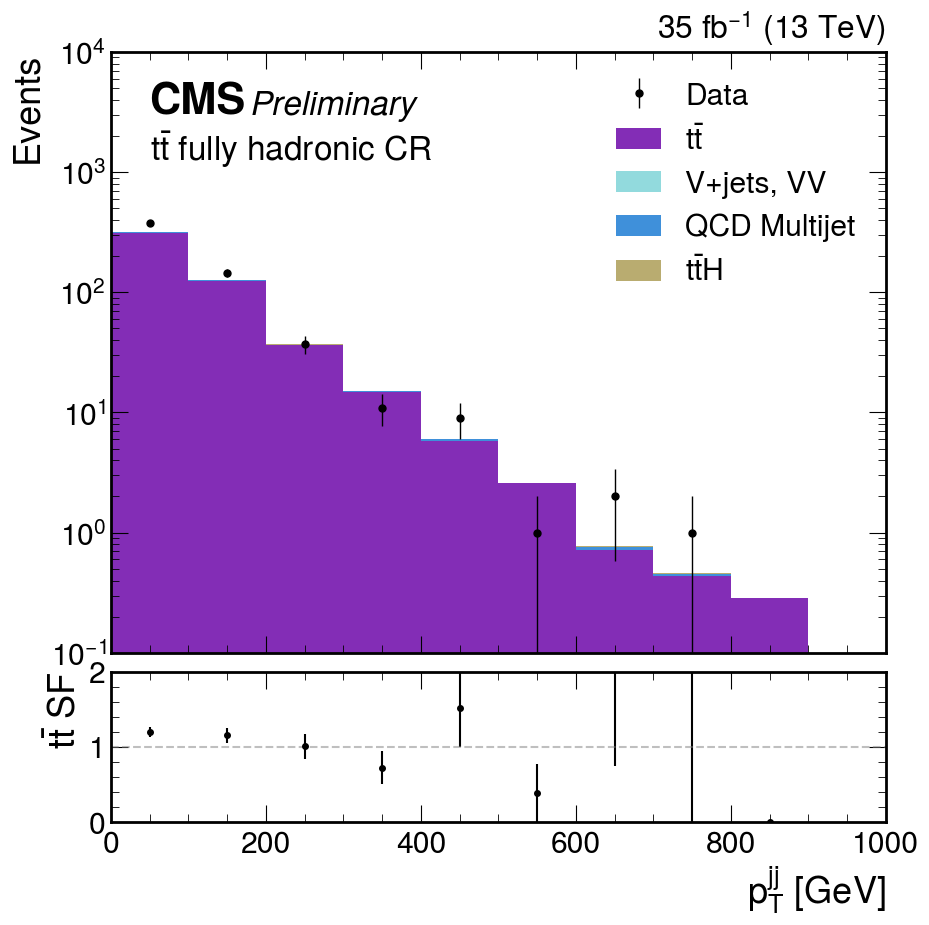

Year: 2023, Ratios: [1.04971302 1.06363558 1.41211967 1.34530247 1.28439646 0.96692856
 0.59848638 1.         1.         1.        ]


/tmp/ipykernel_3609956/356459340.py:170: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


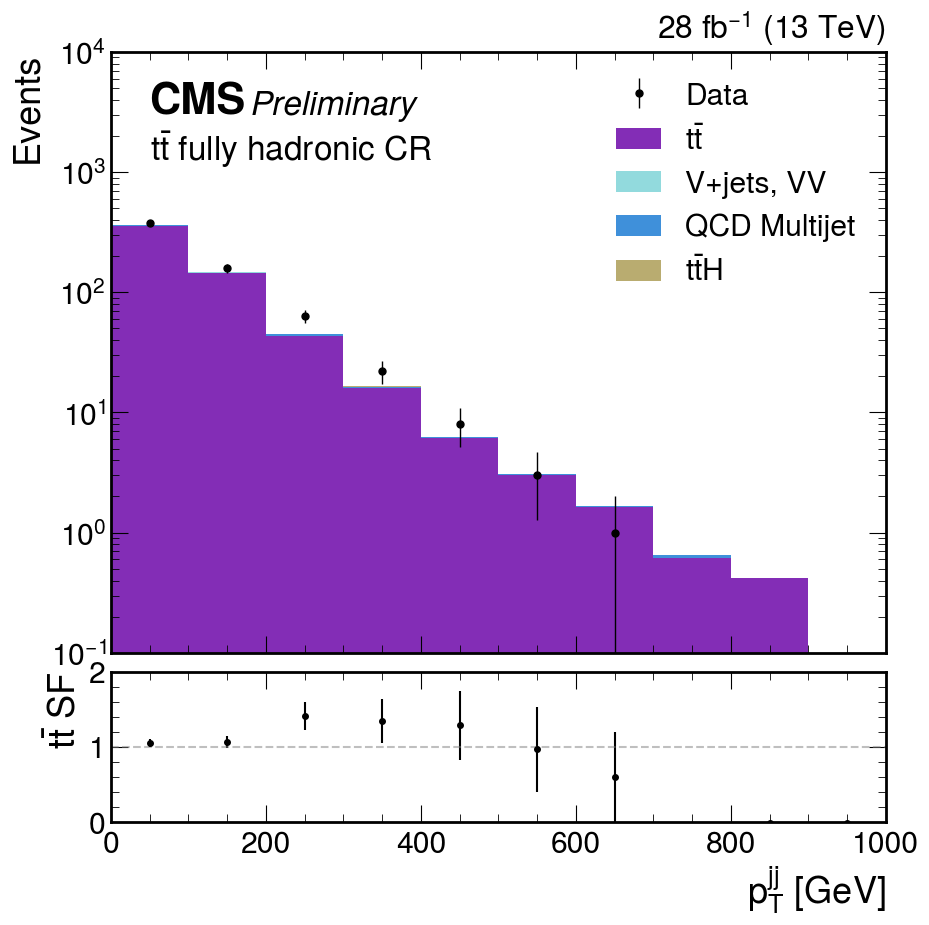

In [12]:
sf_dict = {}

for year, trees in tree_dict.items():
    # Create figure with subplots (2:1 ratio)
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 10), 
        gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.05}
    )
    
    # Initialize storage for histograms
    ttbar_hist = None
    ttbar_hist_up = None
    ttbar_hist_down = None
    bkg_hists = []  # MC background (MC - ttbar)
    
    # MC
    mc_hists = []
    mc_labels = []
    mc_colors = []
    for sample_name in mc_stack_order:
        if sample_name == "VV+VJ":
            feature = np.concatenate([
                feature_dict[year]["VJ"][feature_name],
                feature_dict[year]["VV"][feature_name],
            ])
            weights = np.concatenate([
                feature_dict[year]["VJ"]["weight"],
                feature_dict[year]["VV"]["weight"],
            ])
        else:
            feature = feature_dict[year][sample_name][feature_name]
            weights = feature_dict[year][sample_name]["weight"]
    
        weights = weights * kfact[year]
        if sample_name == "ttbar":
            # Apply SF correction
            tau32 = feature_dict[year][sample_name]["fatJet1_Tau3OverTau2"]
            cset = corr_dict["tau32"][year]
            corr = cset["ttbar_SF_tau32"]
            sf_nom = corr.evaluate(tau32, "nominal")
            weights = weights * sf_nom
            
            txbb = feature_dict[year][sample_name]["fatJet1_GloParT_XbbVsQCD"]
            cset_txbb = corr_dict["TXbb"][year]
            corr_txbb = cset_txbb["ttbar_SF_TXbb"]
            sf_nom = corr_txbb.evaluate(txbb, "nominal")
            weights = weights * sf_nom

        # Calculate histogram
        counts, _ = np.histogram(feature, bins=bins, weights=weights)
        mc_hists.append(counts)
        mc_labels.append(legend_label_dict[sample_name])
        mc_colors.append(color_dict[sample_name])
        
        if sample_name == "ttbar":
            ttbar_hist = counts
        else:
            bkg_hists.append(counts)
    
    if bkg_hists:
        total_bkg = np.sum(bkg_hists, axis=0)
    else:
        total_bkg = np.zeros_like(data_hist)
        
    hep.histplot(
        mc_hists,
        bins=bins,
        stack=True,
        histtype="fill",
        color=mc_colors,
        label=mc_labels,
        ax=ax1
    )
    
    # Data
    feature = feature_dict[year]["data"][feature_name]
    weights = feature_dict[year]["data"]["weight"]
    counts, edges = np.histogram(feature, bins=bins, weights=weights)
    data_hist = counts
    data_err = np.sqrt(counts)
    hep.histplot(
        (counts, edges),
        label=legend_label_dict["data"],
        xerr=False,
        yerr=data_err,
        ax=ax1,
        color="black",
        histtype="errorbar",
    )
    
    # Reorder legend to put data first
    handles, labels = ax1.get_legend_handles_labels()
    data_handle = handles[-1]
    data_label = labels[-1]
    new_handles = [data_handle] + handles[:-1]
    new_labels = [data_label] + labels[:-1]
    leg = ax1.legend(new_handles, new_labels, loc="upper right")
    # # ax1.legend(new_handles, new_labels, bbox_to_anchor=(1.03, 1), loc="upper left")
    # # Patch
    # for handle in leg.get_patches():
    #     handle.set_edgecolor('black')
    #     handle.set_linewidth(1.5)
        
    # Top subplot formatting
    ax1.set_ylabel("Events")
    if year in ylim_dict:
        ax1.set_ylim(ylim_dict[year])
    ax1.set_yscale("log")
    ax1.set_xticklabels([])  # Hide x-axis labels for top plot
    # ax1.grid(True, alpha=0.3)
    
    # Derive scale factors
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = (data_hist - total_bkg) / ttbar_hist
        mask = (ttbar_hist == 0) | (ratio < 0) | (ratio > 2)
        sf = ratio.copy()
        sf[mask] = 1  # Set to 1 where TTbar is 0 or SF is out of bounds
        print(f"Year: {year}, Ratios: {sf}")
        
        ratio_err = data_err / ttbar_hist
        sf_err = ratio_err.copy()
        sf_err[mask] = 0
        
        sf_dict[year] = {
            "SF": sf,
            "err": sf_err,
        }
    
    # Plot ratio
    bin_centers = (edges[:-1] + edges[1:]) / 2
    bin_widths = edges[1:] - edges[:-1]    
    ax2.errorbar(
        bin_centers, 
        ratio, 
        yerr=ratio_err, 
        xerr=False, 
        fmt='ko', 
        markersize=4, 
        capsize=0
    )
    ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    
    # Bottom subplot formatting
    ax2.set_xlabel(r"$p_{T}^{jj}$ [GeV]")
    ax2.set_ylabel(r"$t\bar{t}$ SF")
    ax2.set_ylim(0, 2)  # Adjust as needed
    # ax2.grid(True, alpha=0.3)
    
    for ax in (ax1, ax2):
        ax.set_xlim(bins[0], bins[-1])
    
    hep.cms.label(
        "Preliminary",
        fontsize=24,
        data=True,
        lumi=f"{LUMI_DICT[year] / 1e3:.0f}",
        year=None,
        ax=ax1,
        com="13",
        loc=1,
    )
    
    title = r"$t\bar{t}$ fully hadronic CR"
    x_text = 0.02
    # y_text = 0.78
    y_text = 0.76
    ax1.text(x_text + 0.03, y_text + 0.06, title, fontsize=24, transform=ax1.transAxes)
    

    plt.tight_layout()
    plt.savefig(plot_dir / f"{feature_name}_{year}.pdf", bbox_inches='tight')
    plt.show()

In [13]:
for year, sf in sf_dict.items():
    sf_nominal = sf["SF"]
    sf_err = sf["err"]
    sf_up = sf_nominal + sf_err
    sf_down = sf_nominal - sf_err
    edges = bins
    cset = get_corr(edges, sf_nominal, sf_up, sf_down, var_name="pTjj", var_description="FatJet pTjj")
    with open(sf_dir / f"corr_{feature_label}_{year}.json", "w") as fout:
        fout.write(cset.model_dump_json(exclude_unset=True))
        
corr_dict[feature_label] = {}
for year in sf_dict:
    corr_file = sf_dir / f"corr_{feature_label}_{year}.json"
    if not corr_file.exists():
        raise FileNotFoundError(f"Correction file {corr_file} does not exist.")

    # Load the correction
    corr = correctionlib.CorrectionSet.from_file(str(corr_file))
    corr_dict[feature_label][year] = corr
    print(f"Loaded correction for {year} from {corr_file}")

Loaded correction for 2022 from SF/corr_pTjj_2022.json
Loaded correction for 2023 from SF/corr_pTjj_2023.json


Year: 2022, Ratios: [ 1.          1.          1.          1.          1.          1.
  2.72849866  2.23421399 -0.00487754 -0.2796838 ]


/tmp/ipykernel_3609956/1993766172.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


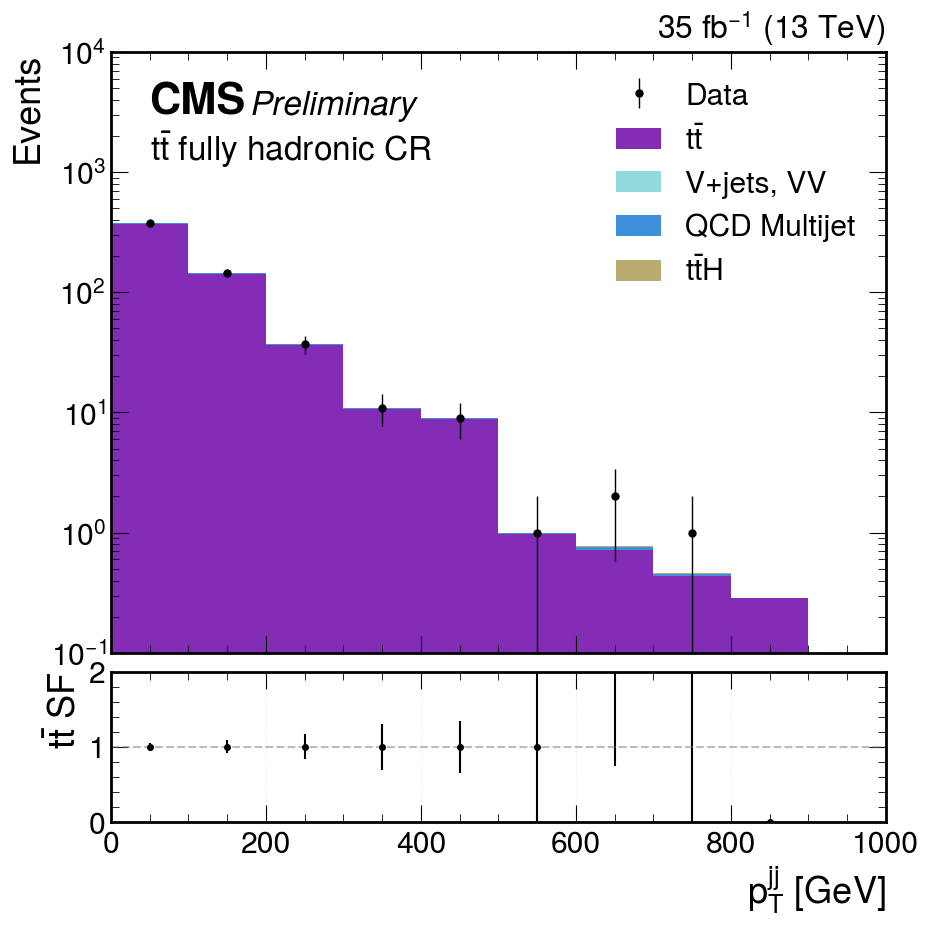

Year: 2023, Ratios: [ 1.          1.          1.          1.          1.          1.
  1.         -0.06024292 -0.0095409  -0.01355259]


/tmp/ipykernel_3609956/1993766172.py:160: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()


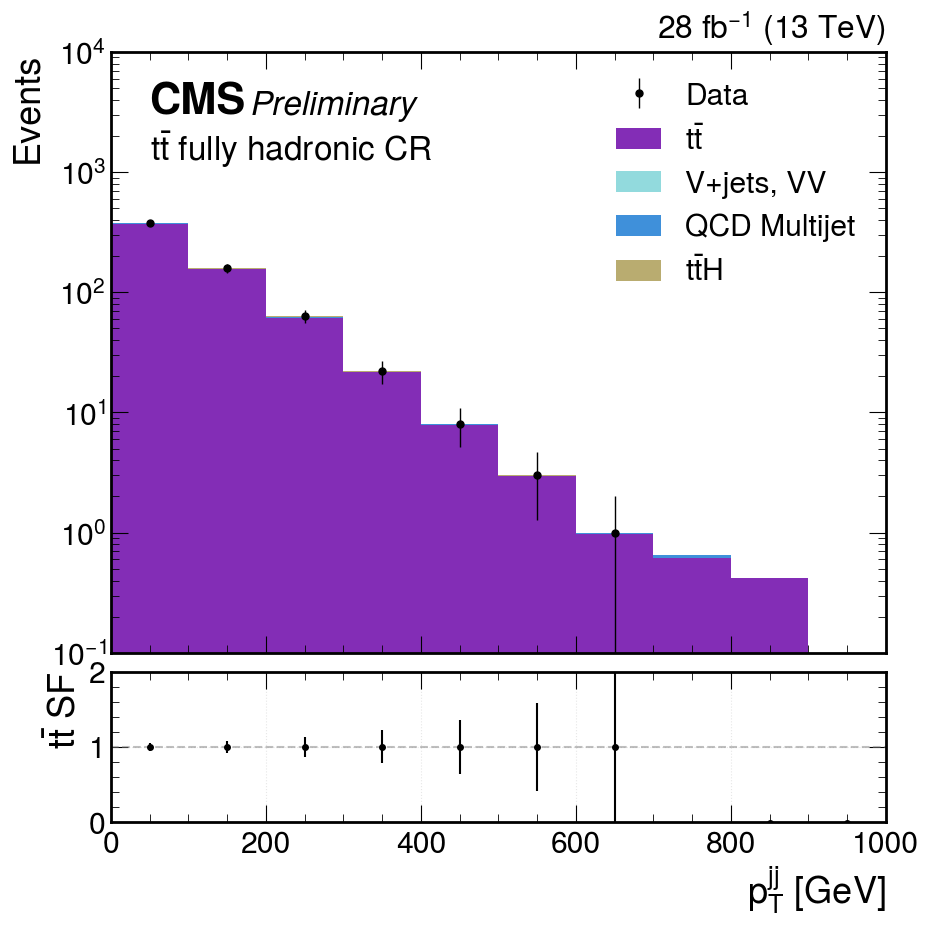

In [14]:
for year, trees in tree_dict.items():
    # Create figure with subplots (2:1 ratio)
    fig, (ax1, ax2) = plt.subplots(
        2, 1, figsize=(10, 10), 
        gridspec_kw={'height_ratios': [4, 1], 'hspace': 0.05}
    )
    
    # Initialize storage for histograms
    ttbar_hist = None
    bkg_hists = []  # MC background (MC - ttbar)
    
    # MC
    mc_hists = []
    mc_labels = []
    mc_colors = []
    for sample_name in mc_stack_order:
        if sample_name == "VV+VJ":
            feature = np.concatenate([
                feature_dict[year]["VJ"][feature_name],
                feature_dict[year]["VV"][feature_name],
            ])
            weights = np.concatenate([
                feature_dict[year]["VJ"]["weight"],
                feature_dict[year]["VV"]["weight"],
            ])
        else:
            feature = feature_dict[year][sample_name][feature_name]
            weights = feature_dict[year][sample_name]["weight"]
    
        weights = weights * kfact[year]
        if sample_name == "ttbar":
            # Apply SF correction
            tau32 = feature_dict[year][sample_name]["fatJet1_Tau3OverTau2"]
            cset = corr_dict["tau32"][year]
            corr = cset["ttbar_SF_tau32"]
            sf_nom = corr.evaluate(tau32, "nominal")
            weights = weights * sf_nom
            
            txbb = feature_dict[year][sample_name]["fatJet1_GloParT_XbbVsQCD"]
            cset = corr_dict["TXbb"][year]
            corr = cset["ttbar_SF_TXbb"]
            sf_nom = corr.evaluate(txbb, "nominal")
            weights = weights * sf_nom
            
            ptjj = feature_dict[year][sample_name][feature_name]
            cset = corr_dict[feature_label][year]
            corr = cset["ttbar_SF_pTjj"]
            sf_nom = corr.evaluate(ptjj, "nominal")
            weights = weights * sf_nom
        
        # Calculate histogram
        counts, edges = np.histogram(feature, bins=bins, weights=weights)
        mc_hists.append(counts)
        mc_labels.append(legend_label_dict[sample_name])
        mc_colors.append(color_dict[sample_name])
        
        if sample_name == "ttbar":
            ttbar_hist = counts
        else:
            bkg_hists.append(counts)
    
    if bkg_hists:
        total_bkg = np.sum(bkg_hists, axis=0)
    else:
        total_bkg = np.zeros_like(data_hist)
        
    hep.histplot(
        mc_hists,
        bins=bins,
        stack=True,
        histtype="fill",
        color=mc_colors,
        label=mc_labels,
        ax=ax1
    )
    
    # Data
    feature = feature_dict[year]["data"][feature_name]
    weights = feature_dict[year]["data"]["weight"]
    counts, edges = np.histogram(feature, bins=bins, weights=weights)
    data_hist = counts
    data_err = np.sqrt(counts)
    hep.histplot(
        (counts, edges),
        label=legend_label_dict["data"],
        xerr=False,
        yerr=data_err,
        ax=ax1,
        color="black",
        histtype="errorbar",
    )
    
    # Reorder legend to put data first
    handles, labels = ax1.get_legend_handles_labels()
    data_handle = handles[-1]
    data_label = labels[-1]
    new_handles = [data_handle] + handles[:-1]
    new_labels = [data_label] + labels[:-1]
    # leg = ax1.legend(new_handles, new_labels)
    leg = ax1.legend(new_handles, new_labels, loc="upper right")
    # for handle in leg.get_patches():
    #     handle.set_edgecolor('black')
    #     handle.set_linewidth(1.5)
        
    # Top subplot formatting
    ax1.set_ylabel("Events")
    if year in ylim_dict:
        ax1.set_ylim(ylim_dict[year])
    ax1.set_yscale("log")
    ax1.set_xticklabels([])  # Hide x-axis labels for top plot
    # ax1.grid(True, alpha=0.3)
    
    # Derive scale factors
    with np.errstate(divide='ignore', invalid='ignore'):
        ratio = (data_hist - total_bkg) / ttbar_hist
        print(f"Year: {year}, Ratios: {ratio}")
        ratio_err = data_err / ttbar_hist
    
    # Plot ratio
    bin_centers = (edges[:-1] + edges[1:]) / 2
    bin_widths = edges[1:] - edges[:-1]    
    ax2.errorbar(
        bin_centers, 
        ratio, 
        yerr=ratio_err, 
        xerr=False, 
        fmt='ko', 
        markersize=4, 
        capsize=0
    )
    ax2.axhline(y=1, color='gray', linestyle='--', alpha=0.5)
    
    # Bottom subplot formatting
    ax2.set_xlabel(r"$p_{T}^{jj}$ [GeV]")
    ax2.set_ylabel(r"$t\bar{t}$ SF")
    ax2.set_ylim(0, 2)
    ax2.grid(True, alpha=0.3)
    
    for ax in (ax1, ax2):
        ax.set_xlim(bins[0], bins[-1])
    
    hep.cms.label(
        "Preliminary",
        fontsize=24,
        data=True,
        lumi=f"{LUMI_DICT[year] / 1e3:.0f}",
        year=None,
        ax=ax1,
        com="13",
        loc=1,
    )
    
    title = r"$t\bar{t}$ fully hadronic CR"
    x_text = 0.02
    # y_text = 0.78
    y_text = 0.76
    ax1.text(x_text + 0.03, y_text + 0.06, title, fontsize=24, transform=ax1.transAxes)
    

    plt.tight_layout()
    plt.savefig(plot_dir / f"{feature_name}_{year}-postcorr.pdf", bbox_inches='tight')
    plt.show()